# Практичне завдання №2: безпечна MAS для перевірки українського тексту

Notebook дублює основний Python workflow логічними блоками: JSON-вхід → guardrails → supervisor і спеціалісти → контрольований RAG → verifier → HITL → виправлена копія → CrewAI parity → MCP і тести.

**Важливо:** текст документа вважається недовіреними даними. Оригінальний JSON не мутується, а адміністративні функції агентам недоступні.

## 1. Імпорти та відтворюваний вхід

In [42]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import display, Markdown, JSON, HTML

PROJECT_DIRNAME = "Task_002_Pylypenko_UA_Language_MAS"
cwd = Path.cwd().resolve()
bases = [cwd, *cwd.parents]
candidates = [*bases, *(base / PROJECT_DIRNAME for base in bases)]
ROOT = next(
    (path for path in candidates if (path / "language_mas").is_dir() and (path / "mcp_server.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError(
        f"Не знайдено каталог {PROJECT_DIRNAME}. "
        "Відкрийте notebook із каталогу завдання або його батьківської робочої папки."
    )

# VS Code/Jupyter може запускати kernel із батьківської папки workspace.
# Додаємо знайдений проєкт до import path і використовуємо його для всіх відносних шляхів.
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Корінь проєкту: {ROOT}")

# Якщо kernel уже виконував старішу версію проєкту, Python тримає її в sys.modules.
# Очищаємо лише модулі цього навчального пакета, щоб повторний Run All читав актуальні файли.
for module_name in list(sys.modules):
    if module_name == "language_mas" or module_name.startswith("language_mas.") or module_name == "mcp_server":
        del sys.modules[module_name]

from language_mas.fixtures import load_fixture, demo_review_payload
from language_mas.knowledge import SecureKnowledgeBase
from language_mas.langgraph_mas import create_langgraph_mas
from language_mas.crewai_mas import create_crewai_mas
from language_mas.models import ActorContext
from language_mas.reporting import render_text_report, render_corrected_document, save_corrected_document
from language_mas.document_ingestion import DocumentIntakeAgent
from language_mas.audit import JsonlTracer

REQUEST = load_fixture()
ACTOR = ActorContext(tenant_id="notebook-tenant", user_id="notebook-user")
THREAD_ID = "notebook-language-demo"
display(JSON(REQUEST))

Корінь проєкту: C:\Study\AI_agent_LLM\Task_002_Pylypenko_UA_Language_MAS


<IPython.core.display.JSON object>

## 2. Архітектура та мінімальні права

In [43]:
roles = pd.DataFrame([
    ["Document Intake Agent", "Вибір parser і перетворення файла у JSON без мовних змін", "Лише fixtures/documents і parse_document"],
    ["Supervisor", "Маршрутизація, бюджети, агрегація статусів", "Лише метадані запиту; без tools редагування"],
    ["Grammar Agent", "Орфографія, пунктуація, граматика, узгодження та відмінювання", "Потрібні node.text, правила правопису і словозміни"],
    ["Style Agent", "Кальки, канцеляризми, ясність, лаконічність, офіційні формулювання", "Поточний документ і правила стилю"],
    ["Terminology Agent", "Узгодженість термінів і користувацького глосарія", "Документ і owner-scoped glossary поточного користувача"],
    ["Structure Agent", "Повтори, нумерація, посилання, довгі або дубльовані фрагменти", "node_id, порядок, заголовки та потрібний текст"],
    ["Verifier Agent", "Evidence, confidence, збереження цифр, назв і фактів", "Findings, відповідні фрагменти та retrieved rules"],
], columns=["Агент", "Функція", "Доступ лише до"])
display(roles)

,Агент,Функція,Доступ лише до
0,Document Intake Agent,Вибір parser і перетворення файла у JSON без м...,Лише fixtures/documents і parse_document
1,Supervisor,"Маршрутизація, бюджети, агрегація статусів",Лише метадані запиту; без tools редагування
2,Grammar Agent,"Орфографія, пунктуація, граматика, узгодження ...","Потрібні node.text, правила правопису і словоз..."
3,Style Agent,"Кальки, канцеляризми, ясність, лаконічність, о...",Поточний документ і правила стилю
4,Terminology Agent,Узгодженість термінів і користувацького глосарія,Документ і owner-scoped glossary поточного кор...
5,Structure Agent,"Повтори, нумерація, посилання, довгі або дубль...","node_id, порядок, заголовки та потрібний текст"
6,Verifier Agent,"Evidence, confidence, збереження цифр, назв і ...","Findings, відповідні фрагменти та retrieved rules"


## 3. Візуалізований intake: TXT, DOCX, PDF і зображення

In [44]:
intake = DocumentIntakeAgent(trace_path=ROOT / "traces" / "notebook_intake_secure.jsonl")
files = ["example.txt", "example.docx", "example.pdf", "example.png"]
INTAKE_RESULTS = {
    name: intake.parse(name, request_id=f'notebook-{Path(name).suffix[1:]}')
    for name in files
}

rows = []
for name, result in INTAKE_RESULTS.items():
    assert result["status"] == "ok", result
    source = result["data"]["source"]
    nodes = result["data"]["request"]["document"]["nodes"]
    rows.append({
        "Файл": name,
        "Формат": source["format"].upper(),
        "Розмір, байт": source["size_bytes"],
        "Метод": source["extraction_method"],
        "Статус": result["status"],
        "JSON-вузлів": len(nodes),
        "Текст": " ".join(node["text"] for node in nodes)[:120],
        "Попередження": "; ".join(source["warnings"]) or "—",
    })

display(pd.DataFrame(rows))

# Візуальна звірка: зліва оригінальна сторінка/файл, справа JSON саме для передачі в MAS.
import base64, html, io
from docx import Document as WordDocument
from PIL import Image as PILImage
import pdfplumber

def image_data_uri(image):
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")

def original_preview(name):
    path = ROOT / "fixtures" / "documents" / name
    suffix = path.suffix.lower()
    if suffix == ".txt":
        body = html.escape(path.read_text(encoding="utf-8"))
        return f'<div class="paper"><pre>{body}</pre></div>'
    if suffix == ".docx":
        parts = []
        for paragraph in WordDocument(path).paragraphs:
            if not paragraph.text.strip():
                continue
            tag = "h3" if paragraph.style.name.startswith("Heading") else "p"
            parts.append(f'<{tag}>{html.escape(paragraph.text)}</{tag}>')
        return '<div class="paper">' + "".join(parts) + '</div>'
    if suffix == ".pdf":
        with pdfplumber.open(path) as pdf:
            images = [page.to_image(resolution=100).original for page in pdf.pages]
        return "".join(
            f'<p><b>Сторінка {index}</b></p><img class="page-image" src="{image_data_uri(image)}" alt="Сторінка {index} PDF">'
            for index, image in enumerate(images, start=1)
        )
    with PILImage.open(path) as image:
        return f'<img class="page-image" src="{image_data_uri(image.copy())}" alt="Вхідне зображення">'

def show_document_pipeline(name):
    result = INTAKE_RESULTS[name]
    transfer_json = html.escape(json.dumps(result["data"]["request"], ensure_ascii=False, indent=2))
    source = result["data"]["source"]
    warning = "; ".join(source["warnings"]) or "немає"
    display(Markdown(
        f'### {name}\n\n'
        f'[Відкрити оригінальний файл](./fixtures/documents/{name})  \n'
        f'**Метод розпізнавання:** `{source["extraction_method"]}` · '
        f'**Статус:** `{result["status"]}` · **JSON-вузлів:** `{len(result["data"]["request"]["document"]["nodes"])}`'
    ))
    display(HTML(f'''<style>
      .compare-grid {{display:grid;grid-template-columns:minmax(300px,1fr) minmax(380px,1fr);gap:18px;align-items:start}}
      .compare-panel {{border:1px solid #777;border-radius:8px;padding:12px;overflow:auto;max-height:620px}}
      .paper {{background:white;color:#111;min-height:300px;padding:38px;box-shadow:0 2px 10px #0003;font:17px/1.5 Georgia,serif}}
      .paper pre {{white-space:pre-wrap;font:16px/1.5 Consolas,monospace}}
      .page-image {{display:block;max-width:100%;height:auto;margin:auto;background:white}}
      .json-transfer {{white-space:pre-wrap;overflow-wrap:anywhere;font:13px/1.35 Consolas,monospace}}
      @media(max-width:900px) {{.compare-grid {{grid-template-columns:1fr}}}}
    </style>
    <p><b>Попередження:</b> {html.escape(warning)}</p>
    <div class="compare-grid">
      <section><h4>1. Фізичний вигляд оригіналу</h4><div class="compare-panel">{original_preview(name)}</div></section>
      <section><h4>2. JSON, переданий у LangGraph MAS</h4><div class="compare-panel"><pre class="json-transfer">{transfer_json}</pre></div></section>
    </div>'''))

    analysis = DOCUMENT_ANALYSES[name]
    agent_outputs = analysis["agent_results"]
    display(Markdown("#### 3. Результати перевірки саме цього JSON"))
    display(pd.DataFrame([{
        "Агент": agent_name,
        "Статус": agent_outputs[agent_name]["status"],
        "Знахідок": agent_outputs[agent_name].get(
            "finding_count", agent_outputs[agent_name].get("verified_count", 0)
        ),
    } for agent_name in ("grammar", "style", "terminology", "structure", "verifier")]))

    verified = agent_outputs["verifier"]["findings"]
    display(pd.DataFrame([{
        "Агент": item["agent"],
        "Розташування в оригіналі": f'{item.get("section_ref") or "Фрагмент"} · {item["node_id"]}',
        "Категорія": item["category"],
        "Було": item["original_text"],
        "Пропонується": item.get("suggested_fix") or "Потрібне рішення людини",
        "Пояснення": item["reason"],
        "Впевненість": f'{item["confidence"]:.0%}',
    } for item in verified]).fillna("—"))

assert all(item["status"] == "ok" for item in INTAKE_RESULTS.values())
assert {item["data"]["source"]["format"] for item in INTAKE_RESULTS.values()} == {"txt", "docx", "pdf", "png"}

# Кожен JSON, створений Document Intake Agent, окремо проходить той самий LangGraph MAS.
DOCUMENT_ANALYSES = {}
for name, intake_result in INTAKE_RESULTS.items():
    parsed_mas = create_langgraph_mas()
    parsed_thread = f'parsed-{Path(name).suffix[1:]}'
    parsed_mas.start(intake_result["data"]["request"], ACTOR, thread_id=parsed_thread)
    DOCUMENT_ANALYSES[name] = parsed_mas.result(ACTOR, thread_id=parsed_thread)

assert all(result["agent_results"]["verifier"]["status"] == "completed" for result in DOCUMENT_ANALYSES.values())

,Файл,Формат,"Розмір, байт",Метод,Статус,JSON-вузлів,Текст,Попередження
0,example.txt,TXT,925,utf8_text,ok,9,НАВЧАЛЬНИЙ НАКАЗ (усі ПІБ вигадані) На мою дум...,—
1,example.docx,DOCX,37087,python_docx,ok,10,Приклад DOCX СЛУЖБОВА ЗАПИСКА (усі ПІБ вигадан...,—
2,example.pdf,PDF,51390,pypdf_text_layer,ok,11,НАВЧАЛЬНИЙ ПРОТОКОЛ (усі ПІБ вигадані) На мою ...,—
3,example.png,PNG,48550,fixture_metadata_test_double,ok,7,НАВЧАЛЬНЕ ОГОЛОШЕННЯ (усі ПІБ вигадані) На мою...,Tesseract не встановлено: для fixture використ...


## 3.1. Оригінал → JSON → результати мовних агентів

Нижче кожен контрольний документ із навмисними помилками показано в **окремій клітинці**. Ліворуч міститься фізичний вигляд файлу, праворуч — точний JSON, який Document Intake Agent передав у LangGraph MAS. Під ними наведено знайдені орфографічні, пунктуаційні, граматичні, стилістичні, термінологічні та структурні проблеми.

In [45]:
show_document_pipeline("example.txt")

### example.txt

[Відкрити оригінальний файл](./fixtures/documents/example.txt)  
**Метод розпізнавання:** `utf8_text` · **Статус:** `ok` · **JSON-вузлів:** `9`

#### 3. Результати перевірки саме цього JSON

,Агент,Статус,Знахідок
0,grammar,completed,6
1,style,completed,4
2,terminology,completed,1
3,structure,completed,3
4,verifier,completed,14


,Агент,Розташування в оригіналі,Категорія,Було,Пропонується,Пояснення,Впевненість
0,grammar,Рядок 3 · n-003,grammar,згідно наказу,згідно з наказом,Прийменник «згідно з» керує орудним відмінком.,99%
1,grammar,Рядок 4 · n-004,orthography,будьласка,будь ласка,Словосполучення «будь ласка» пишемо окремо.,99%
2,style,Рядок 6 · n-006,calque,прийняти міри,вжити заходів,Кальковане словосполучення замінюємо нормативн...,99%
3,structure,Рядок 7 · n-007,structure,Повторюваний фрагмент доручення.,Потрібне рішення людини,Однаковий фрагмент повторюється у вузлах: n-00...,99%
4,grammar,Рядок 3 · n-003,grammar,приймати участь,брати участь,Нормативна конструкція — «брати участь».,98%
5,style,Рядок 5 · n-005,calque,співпадає,збігається,У цьому значенні нормативно вживати «збігається».,98%
6,grammar,Рядок 3 · n-003,grammar,олексія коваленко,Олексія Коваленка,Чоловіче прізвище Коваленко в цьому контексті ...,96%
7,structure,Рядок 6 · n-006,structure,план план,план,Сусіднє повторення того самого слова може бути...,96%
8,grammar,Рядок 4 · n-004,grammar,ігорю журавель,Ігорю Журавлю,Чоловіче прізвище Журавель у давальному відмін...,95%
9,structure,Рядок 5 · n-005,structure,основна суть,суть,"Слово «суть» уже позначає основне, тому означе...",94%


In [46]:
show_document_pipeline("example.docx")

### example.docx

[Відкрити оригінальний файл](./fixtures/documents/example.docx)  
**Метод розпізнавання:** `python_docx` · **Статус:** `ok` · **JSON-вузлів:** `10`

#### 3. Результати перевірки саме цього JSON

,Агент,Статус,Знахідок
0,grammar,completed,3
1,style,completed,7
2,terminology,completed,1
3,structure,completed,3
4,verifier,completed,14


,Агент,Розташування в оригіналі,Категорія,Було,Пропонується,Пояснення,Впевненість
0,style,Абзац 5 · n-005,calque,заключити договір,укласти договір,Нормативне українське словосполучення — «уклас...,99%
1,grammar,Абзац 6 · n-006,orthography,будьласка,будь ласка,Словосполучення «будь ласка» пишемо окремо.,99%
2,structure,Абзац 9 · n-009,structure,Однаковий підсумковий абзац.,Потрібне рішення людини,Однаковий фрагмент повторюється у вузлах: n-00...,99%
3,style,Абзац 5 · n-005,calque,слідуючий,наступний,У значенні черговості нормативною є форма «нас...,98%
4,grammar,Абзац 7 · n-007,calque,на протязі,протягом,Для позначення часу нормативно вжити «протягом».,98%
5,style,Абзац 3 · n-003,calque,по питанню,щодо,Кальковану конструкцію замінюємо нормативним п...,97%
6,style,Абзац 3 · n-003,calque,по питанню,щодо,Кальковану конструкцію варто замінити норматив...,96%
7,style,Абзац 3 · n-003,calque,являється,є,У значенні зв’язки нормативною є форма «є».,96%
8,grammar,Абзац 4 · n-004,grammar,тарасом бондар,Тарасом Бондарем,Чоловіче прізвище Бондар відмінюємо як відпові...,96%
9,structure,Абзац 8 · n-008,structure,Рішення рішення,Рішення,Сусіднє повторення того самого слова може бути...,96%


### example.pdf

[Відкрити оригінальний файл](./fixtures/documents/example.pdf)  
**Метод розпізнавання:** `pypdf_text_layer` · **Статус:** `ok` · **JSON-вузлів:** `11`


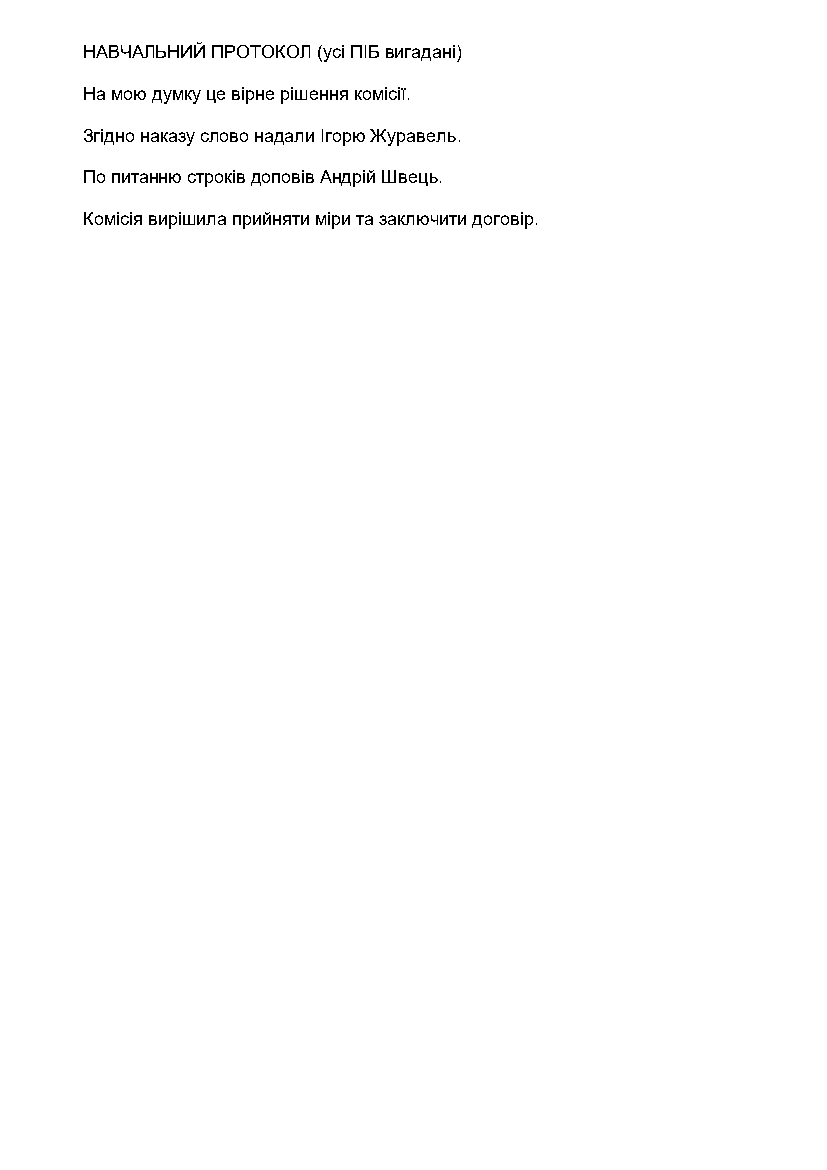
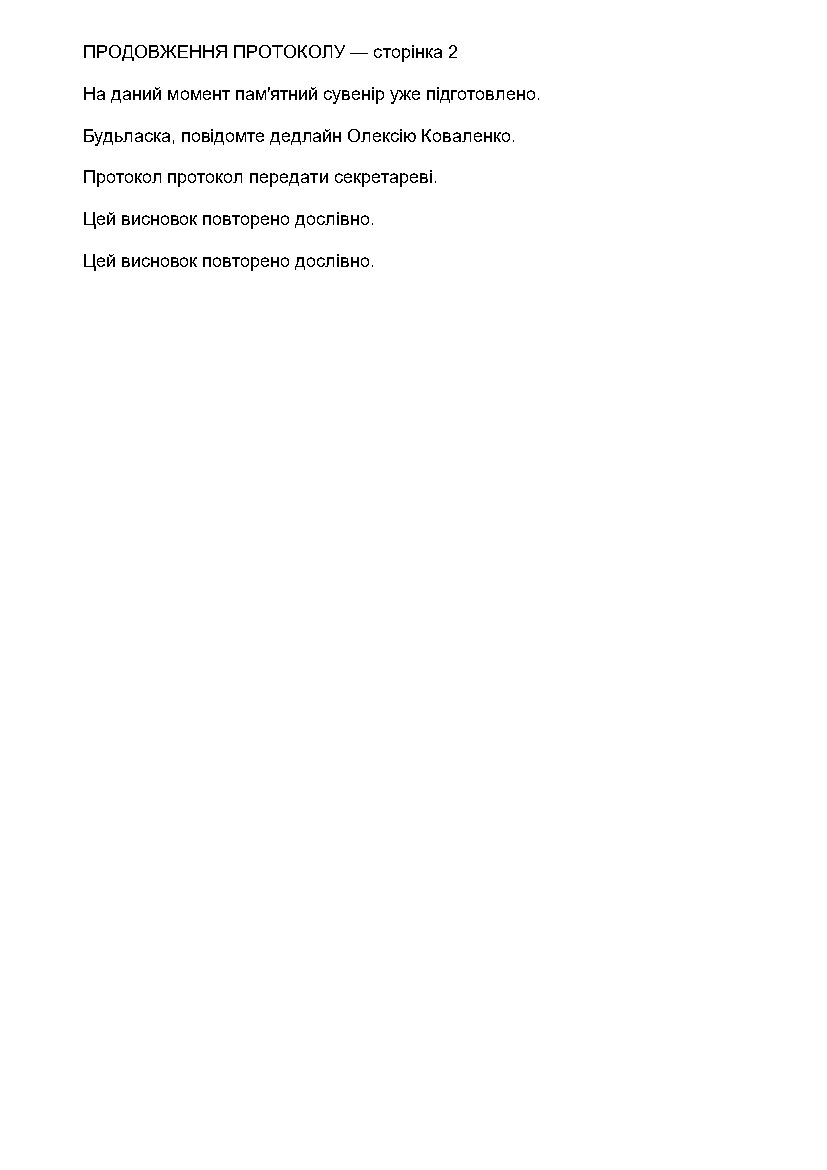

#### 3. Результати перевірки саме цього JSON

,Агент,Статус,Знахідок
0,grammar,completed,5
1,style,completed,6
2,terminology,completed,1
3,structure,completed,3
4,verifier,completed,15


,Агент,Розташування в оригіналі,Категорія,Було,Пропонується,Пояснення,Впевненість
0,grammar,"Сторінка 1, рядок 3 · n-003",grammar,згідно наказу,згідно з наказом,Прийменник «згідно з» керує орудним відмінком.,99%
1,style,"Сторінка 1, рядок 5 · n-005",calque,заключити договір,укласти договір,Нормативне українське словосполучення — «уклас...,99%
2,style,"Сторінка 1, рядок 5 · n-005",calque,прийняти міри,вжити заходів,Кальковане словосполучення замінюємо нормативн...,99%
3,grammar,"Сторінка 2, рядок 3 · n-008",orthography,будьласка,будь ласка,Словосполучення «будь ласка» пишемо окремо.,99%
4,structure,"Сторінка 2, рядок 5 · n-010",structure,Цей висновок повторено дослівно.,Потрібне рішення людини,Однаковий фрагмент повторюється у вузлах: n-01...,99%
5,style,"Сторінка 1, рядок 2 · n-002",calque,вірне рішення,правильне рішення,«Вірний» означає відданий; щодо рішення нормат...,97%
6,style,"Сторінка 1, рядок 4 · n-004",calque,по питанню,щодо,Кальковану конструкцію замінюємо нормативним п...,97%
7,style,"Сторінка 1, рядок 4 · n-004",calque,по питанню,щодо,Кальковану конструкцію варто замінити норматив...,96%
8,grammar,"Сторінка 2, рядок 3 · n-008",grammar,олексію коваленко,Олексію Коваленку,Чоловіче прізвище Коваленко в давальному відмі...,96%
9,structure,"Сторінка 2, рядок 4 · n-009",structure,Протокол протокол,Протокол,Сусіднє повторення того самого слова може бути...,96%


In [47]:
show_document_pipeline("example.pdf")

### example.png

[Відкрити оригінальний файл](./fixtures/documents/example.png)  
**Метод розпізнавання:** `fixture_metadata_test_double` · **Статус:** `ok` · **JSON-вузлів:** `7`


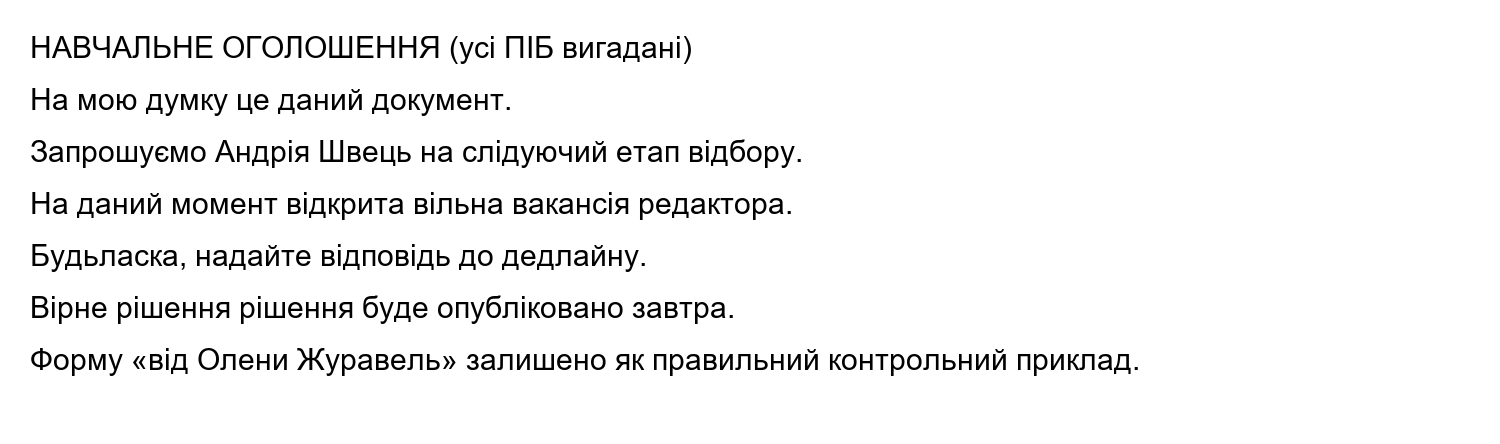

#### 3. Результати перевірки саме цього JSON

,Агент,Статус,Знахідок
0,grammar,completed,3
1,style,completed,4
2,terminology,completed,1
3,structure,completed,2
4,verifier,completed,10


,Агент,Розташування в оригіналі,Категорія,Було,Пропонується,Пояснення,Впевненість
0,grammar,"Зображення, рядок 5 · n-005",orthography,будьласка,будь ласка,Словосполучення «будь ласка» пишемо окремо.,99%
1,style,"Зображення, рядок 3 · n-003",calque,слідуючий,наступний,У значенні черговості нормативною є форма «нас...,98%
2,style,"Зображення, рядок 6 · n-006",calque,вірне рішення,правильне рішення,«Вірний» означає відданий; щодо рішення нормат...,97%
3,structure,"Зображення, рядок 6 · n-006",structure,рішення рішення,рішення,Сусіднє повторення того самого слова може бути...,96%
4,grammar,"Зображення, рядок 3 · n-003",grammar,андрія швець,Андрія Швеця,Чоловіче прізвище Швець у родовому відмінку ма...,95%
5,structure,"Зображення, рядок 4 · n-004",structure,вільна вакансія,вакансія,Вакансія вже означає вільну посаду.,94%
6,style,"Зображення, рядок 2 · n-002",calque,даний документ,цей документ,У цьому значенні природніше використати займен...,93%
7,style,"Зображення, рядок 4 · n-004",calque,на даний момент,нині,Для офіційного тексту доречніше лаконічне «нин...,93%
8,grammar,"Зображення, рядок 2 · n-002",punctuation,На мою думку,"На мою думку,",Вставну конструкцію відокремлюємо комою.,91%
9,terminology,"Зображення, рядок 5 · n-005",terminology,дедлайн,кінцевий строк,Запропоновано нейтральний український термін.,90%


In [48]:
show_document_pipeline("example.png")

## 4. Контрольована база знань

In [49]:
kb = SecureKnowledgeBase()
sources = pd.DataFrame([{
    "ID правила": item["rule_id"],
    "Назва": item["title"],
    "Установа": item["authority"],
    "Версія": item["version"],
    "Довіра": item["trust_level"],
    "Джерело": item["source_url"],
} for item in kb.entries])
display(sources.fillna("—"))
print(f"Перевірених записів: {len(kb.entries)}; checksum кожного запису валідовано під час завантаження.")

,ID правила,Назва,Установа,Версія,Довіра,Джерело
0,GRAM.CASE.001,Керування прийменниково-відмінковими формами,Міністерство освіти і науки України,Офіційне видання 2026,1.00,https://mon.gov.ua/static-objects/mon/sites/1/...
1,GRAM.ORTHO.001,Нормативне написання слів і словосполучень,Національна комісія зі стандартів державної мови,Стандарт державної мови 2026,1.00,https://mova.gov.ua/diyalnist-i-proyekti/termi...
2,STYLE.OFFICIAL.001,Нейтральність і точність офіційного викладу,Національна комісія зі стандартів державної мови,Каталог стандартів 2026,0.95,https://mova.gov.ua/diyalnist-i-proyekti/termini
3,TERM.STATE.001,Стандартизація української термінології,Національна комісія зі стандартів державної мови,Каталог стандартів 2026,1.00,https://mova.gov.ua/diyalnist-i-proyekti/termini
4,MORPH.WORDFORM.001,Словозміна української мови,Український мовно-інформаційний фонд НАН України,Електронна система Словники України,0.95,https://lcorp.ulif.org.ua/pdf/Pro_Systemu.pdf
5,POLICY.LANGUAGE.001,Застосування української мови як державної,Верховна Рада України,Чинна редакція 2026,1.00,https://zakon.rada.gov.ua/go/2704-19


Перевірених записів: 6; checksum кожного запису валідовано під час завантаження.


## 5. LangGraph: явний Plan-and-Execute до Human-in-the-Loop

In [50]:
TRACE_PATH = ROOT / "traces" / "notebook_langgraph_secure.jsonl"
langgraph_mas = create_langgraph_mas(trace_path=TRACE_PATH)
langgraph_mas.start(REQUEST, ACTOR, thread_id=THREAD_ID)
PENDING = langgraph_mas.result(ACTOR, thread_id=THREAD_ID)
print("Статус:", PENDING["status"])
print("Наступний вузол:", PENDING["next"])
print("Однозначних:", len(PENDING["certain_findings"]))
print("Потребують перегляду:", len(PENDING["needs_review"]))

Статус: awaiting_review
Наступний вузол: ['human_review']
Однозначних: 11
Потребують перегляду: 1


## 6. Результати кожного агента

In [51]:
def findings_table(items):
    rows = [{
        "ID": x["finding_id"], "Агент": x["agent"],
        "Розташування": f'{x.get("section_ref") or "Фрагмент"} · {x["node_id"]}',
        "Категорія": x["category"],
        "Було": x["original_text"], "Пропозиція": x.get("suggested_fix") or "—",
        "Причина": x["reason"], "Впевненість": f'{x["confidence"]:.0%}',
        "Джерело": x["evidence"][0]["source_url"] if x.get("evidence") else "—",
    } for x in items]
    return pd.DataFrame(rows).fillna("—")

AGENT_RESULTS = PENDING["agent_results"]
supervisor = AGENT_RESULTS["supervisor"]
verifier = AGENT_RESULTS["verifier"]
display(pd.DataFrame([
    ["Supervisor", supervisor["status"], " → ".join(supervisor["routing_order"]), supervisor["step_count"], supervisor["budget_limit"]],
    ["Verifier", verifier["status"], f'{verifier["received_count"]} отримано / {verifier["verified_count"]} підтверджено', "—", "—"],
], columns=["Агент", "Статус", "Результат/маршрут", "Кроків", "Ліміт"]))

for key, title in [
    ("grammar", "Grammar Agent"),
    ("style", "Style Agent"),
    ("terminology", "Terminology Agent"),
    ("structure", "Structure Agent"),
]:
    output = AGENT_RESULTS[key]
    display(Markdown(f'### {title}: {output["finding_count"]} findings'))
    if output["findings"]:
        display(findings_table(output["findings"]))
    else:
        display(Markdown("Порушень не виявлено."))

display(Markdown("### Verifier Agent: перевірений набір"))
display(pd.DataFrame([{
    "Отримано": verifier["received_count"],
    "Підтверджено": verifier["verified_count"],
    "Відфільтровано": verifier["filtered_count"],
    "Однозначні": verifier["certain_count"],
    "На перегляд": verifier["needs_review_count"],
}]))

display(Markdown("## Наскрізна перевірка кожного розпарсеного документа"))
summary_rows = []
for file_name, analysis in DOCUMENT_ANALYSES.items():
    for agent_name in ("grammar", "style", "terminology", "structure", "verifier"):
        output = analysis["agent_results"][agent_name]
        summary_rows.append({
            "Файл": file_name,
            "Агент": agent_name,
            "Статус": output["status"],
            "Знахідок": output.get("finding_count", output.get("verified_count", 0)),
        })
display(pd.DataFrame(summary_rows))

for file_name, analysis in DOCUMENT_ANALYSES.items():
    outputs = analysis["agent_results"]
    display(Markdown(f"### {file_name}"))
    route = outputs["supervisor"]
    display(pd.DataFrame([{
        "Агент": "Supervisor",
        "Статус": route["status"],
        "Маршрут": " → ".join(route["routing_order"]),
        "Кроків": route["step_count"],
        "Бюджет": route["budget_limit"],
    }]))
    for agent_name, title in [
        ("grammar", "Grammar Agent: орфографія, пунктуація, граматика й відмінювання"),
        ("style", "Style Agent: офіційність, ясність і лаконічність"),
        ("terminology", "Terminology Agent: термінологічна узгодженість"),
        ("structure", "Structure Agent: дублювання і тавтологія"),
    ]:
        output = outputs[agent_name]
        display(Markdown(f'#### {title} — {output["finding_count"]}'))
        if output["findings"]:
            display(findings_table(output["findings"]))
        else:
            display(Markdown("Порушень не виявлено."))
    checked = outputs["verifier"]
    display(Markdown("#### Verifier Agent"))
    display(pd.DataFrame([{
        "Отримано": checked["received_count"],
        "Підтверджено": checked["verified_count"],
        "Відфільтровано": checked["filtered_count"],
        "Однозначні": checked["certain_count"],
        "На перегляд людиною": checked["needs_review_count"],
    }]))
    if checked["findings"]:
        display(findings_table(checked["findings"]))

,Агент,Статус,Результат/маршрут,Кроків,Ліміт
0,Supervisor,completed,grammar → style → terminology → structure → ve...,10,16
1,Verifier,completed,12 отримано / 12 підтверджено,—,—


### Grammar Agent: 6 findings

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-e87bc1128145,grammar,Вступ · p-001,grammar,самим важливим,найважливішим,Форму найвищого ступеня в орудному відмінку ут...,98%,https://mon.gov.ua/static-objects/mon/sites/1/...
1,f-d8e51899a13f,grammar,Основна частина · p-002,grammar,приймати участь,брати участь,Нормативна конструкція — «брати участь».,98%,https://mon.gov.ua/static-objects/mon/sites/1/...
2,f-eaabe10bb937,grammar,Основна частина · p-002,calque,на протязі,протягом,Для позначення часу нормативно вжити «протягом».,98%,—
3,f-92ca56054072,grammar,Основна частина · p-002,grammar,у відповідності до,відповідно до,Нормативне прийменникове сполучення — «відпові...,97%,https://mon.gov.ua/static-objects/mon/sites/1/...
4,f-36efb31743a7,grammar,Умови · p-003,grammar,згідно наказу,згідно з наказом,Прийменник «згідно з» керує орудним відмінком.,99%,https://mon.gov.ua/static-objects/mon/sites/1/...
5,f-c24d3abc4c43,grammar,Контакти · p-004,grammar,дякую Вас,дякую Вам,Дієслово «дякувати» вимагає давального відмінка.,99%,https://mon.gov.ua/static-objects/mon/sites/1/...


### Style Agent: 4 findings

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-03338dcec56d,style,Вступ · p-001,official_style,виходячи з вищесказаного,з огляду на викладене,Офіційніше й лаконічніше формулювання.,94%,https://mova.gov.ua/diyalnist-i-proyekti/termini
1,f-c5d70e70d19f,style,Вступ · p-001,calque,даний документ,цей документ,У цьому значенні природніше використати займен...,93%,https://mova.gov.ua/diyalnist-i-proyekti/termini
2,f-ed27f157765b,style,Вступ · p-001,calque,являється,є,У значенні зв’язки нормативною є форма «є».,96%,https://mova.gov.ua/diyalnist-i-proyekti/termini
3,f-03a5c7d4b281,style,Умови · p-003,official_style,має місце,зазначено,У цьому контексті канцелярську конструкцію дор...,82%,https://mova.gov.ua/diyalnist-i-proyekti/termini


...

#### Structure Agent: дублювання і тавтологія — 2

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-decee87dca75,structure,"Зображення, рядок 4 · n-004",structure,вільна вакансія,вакансія,Вакансія вже означає вільну посаду.,94%,—
1,f-061e648fc9a3,structure,"Зображення, рядок 6 · n-006",structure,рішення рішення,рішення,Сусіднє повторення того самого слова може бути...,96%,—


#### Verifier Agent

,Отримано,Підтверджено,Відфільтровано,Однозначні,На перегляд людиною
0,10,10,0,10,0


,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-5fd3737d6961,grammar,"Зображення, рядок 5 · n-005",orthography,будьласка,будь ласка,Словосполучення «будь ласка» пишемо окремо.,99%,https://mova.gov.ua/diyalnist-i-proyekti/termi...
1,f-093db1b78403,style,"Зображення, рядок 3 · n-003",calque,слідуючий,наступний,У значенні черговості нормативною є форма «нас...,98%,https://mova.gov.ua/diyalnist-i-proyekti/termini
2,f-8996eef89948,style,"Зображення, рядок 6 · n-006",calque,вірне рішення,правильне рішення,«Вірний» означає відданий; щодо рішення нормат...,97%,https://mova.gov.ua/diyalnist-i-proyekti/termini
3,f-061e648fc9a3,structure,"Зображення, рядок 6 · n-006",structure,рішення рішення,рішення,Сусіднє повторення того самого слова може бути...,96%,—
4,f-bc206b9e47f2,grammar,"Зображення, рядок 3 · n-003",grammar,андрія швець,Андрія Швеця,Чоловіче прізвище Швець у родовому відмінку ма...,95%,https://mon.gov.ua/static-objects/mon/sites/1/...
5,f-decee87dca75,structure,"Зображення, рядок 4 · n-004",structure,вільна вакансія,вакансія,Вакансія вже означає вільну посаду.,94%,—
6,f-fbc71998c859,style,"Зображення, рядок 2 · n-002",calque,даний документ,цей документ,У цьому значенні природніше використати займен...,93%,https://mova.gov.ua/diyalnist-i-proyekti/termini
7,f-da2382c8fd3c,style,"Зображення, рядок 4 · n-004",calque,на даний момент,нині,Для офіційного тексту доречніше лаконічне «нин...,93%,https://mova.gov.ua/diyalnist-i-proyekti/termini
8,f-39abb26c20e2,grammar,"Зображення, рядок 2 · n-002",punctuation,На мою думку,"На мою думку,",Вставну конструкцію відокремлюємо комою.,91%,—
9,f-c073b5605ba9,terminology,"Зображення, рядок 5 · n-005",terminology,дедлайн,кінцевий строк,Запропоновано нейтральний український термін.,90%,https://mova.gov.ua/diyalnist-i-proyekti/termini


## 7. Однозначні пропозиції

In [52]:
display(findings_table(PENDING["certain_findings"]))

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-36efb31743a7,grammar,Умови · p-003,grammar,згідно наказу,згідно з наказом,Прийменник «згідно з» керує орудним відмінком.,99%,https://mon.gov.ua/static-objects/mon/sites/1/...
1,f-c24d3abc4c43,grammar,Контакти · p-004,grammar,дякую Вас,дякую Вам,Дієслово «дякувати» вимагає давального відмінка.,99%,https://mon.gov.ua/static-objects/mon/sites/1/...
2,f-e87bc1128145,grammar,Вступ · p-001,grammar,самим важливим,найважливішим,Форму найвищого ступеня в орудному відмінку ут...,98%,https://mon.gov.ua/static-objects/mon/sites/1/...
3,f-d8e51899a13f,grammar,Основна частина · p-002,grammar,приймати участь,брати участь,Нормативна конструкція — «брати участь».,98%,https://mon.gov.ua/static-objects/mon/sites/1/...
4,f-eaabe10bb937,grammar,Основна частина · p-002,calque,на протязі,протягом,Для позначення часу нормативно вжити «протягом».,98%,—
5,f-92ca56054072,grammar,Основна частина · p-002,grammar,у відповідності до,відповідно до,Нормативне прийменникове сполучення — «відпові...,97%,https://mon.gov.ua/static-objects/mon/sites/1/...
6,f-ed27f157765b,style,Вступ · p-001,calque,являється,є,У значенні зв’язки нормативною є форма «є».,96%,https://mova.gov.ua/diyalnist-i-proyekti/termini
7,f-03338dcec56d,style,Вступ · p-001,official_style,виходячи з вищесказаного,з огляду на викладене,Офіційніше й лаконічніше формулювання.,94%,https://mova.gov.ua/diyalnist-i-proyekti/termini
8,f-c5d70e70d19f,style,Вступ · p-001,calque,даний документ,цей документ,У цьому значенні природніше використати займен...,93%,https://mova.gov.ua/diyalnist-i-proyekti/termini
9,f-85152a969752,terminology,Умови · p-003,terminology,дедлайн,кінцевий строк,Запропоновано нейтральний український термін.,90%,https://mova.gov.ua/diyalnist-i-proyekti/termini


## 8. Сумнівні пропозиції — рішення людини

In [53]:
display(findings_table(PENDING["needs_review"]))

# У реальному UI користувач обирає approve/edit/reject для кожної позиції.
REVIEW = demo_review_payload(PENDING)
display(JSON(REVIEW))

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-03a5c7d4b281,style,Умови · p-003,official_style,має місце,зазначено,У цьому контексті канцелярську конструкцію дор...,82%,https://mova.gov.ua/diyalnist-i-proyekti/termini


<IPython.core.display.JSON object>

## 9. Resume і застосування тільки підтверджених правок

In [54]:
langgraph_mas.resume(REVIEW, ACTOR, thread_id=THREAD_ID)
FINAL = langgraph_mas.result(ACTOR, thread_id=THREAD_ID)
print("Фінальний статус:", FINAL["status"])
print("Застосовано:", len(FINAL["applied"]))
print("Відхилено:", len(FINAL["rejected"]))
corrected_text = render_corrected_document(FINAL)

display(Markdown("### Фінальний виправлений текст"))
display(HTML(
    '<div style="background:#f7fff7;color:#111;border:2px solid #38a169;'
    'border-radius:10px;padding:24px;font:17px/1.6 Georgia,serif;white-space:pre-wrap">'
    + html.escape(corrected_text) + '</div>'
))

display(Markdown("### Порівняння оригіналу та погодженої копії"))
original_nodes = {node["node_id"]: node["text"] for node in REQUEST["document"]["nodes"]}
corrected_nodes = {node["node_id"]: node["text"] for node in FINAL["corrected_document"]["nodes"]}
display(pd.DataFrame([{
    "Розташування": node["section_ref"],
    "Оригінал": original_nodes[node["node_id"]],
    "Після HITL": corrected_nodes[node["node_id"]],
} for node in REQUEST["document"]["nodes"]]))

display(Markdown("### JSON виправленої копії"))
display(JSON(FINAL["corrected_document"]))
corrected_path = save_corrected_document(FINAL, ROOT / "outputs" / "notebook_corrected_document.txt")
display(Markdown(f"[Відкрити нову погоджену TXT-копію]({corrected_path.as_posix()})"))
display(Markdown("### Записи, додані до персональної пам’яті після write-gate"))
display(pd.DataFrame(FINAL["memory_updates"]))
assert FINAL["memory_updates"][0]["preferred_text"] == 'кінцевий термін'

Фінальний статус: completed
Застосовано: 12
Відхилено: 0


### Фінальний виправлений текст

### Порівняння оригіналу та погодженої копії

,Розташування,Оригінал,Після HITL
0,Вступ,"Виходячи з вищесказаного, даний документ являє...","З огляду на викладене, цей документ є найважли..."
1,Основна частина,Працівники повинні приймати участь у відповідн...,Працівники повинні брати участь відповідно до ...
2,Умови,Згідно наказу дедлайн погодження договору визн...,Згідно з наказом кінцевий термін погодження до...
3,Контакти,Дякую Вас. Відповідальна особа: editor@example...,Дякую Вам. Відповідальна особа: [EMAIL_REDACTED].


### JSON виправленої копії

<IPython.core.display.JSON object>

[Відкрити нову погоджену TXT-копію](C:/Study/AI_agent_LLM/Task_002_Pylypenko_UA_Language_MAS/outputs/notebook_corrected_document.txt)

### Записи, додані до персональної пам’яті після write-gate

,namespace,original_text,preferred_text,agent,source,confirmed,expires_at
0,"[notebook-tenant, notebook-user, corrections]",дедлайн,кінцевий термін,terminology,human_confirmed_edit,True,2027-09-05T16:11:02.585982+00:00


## 9.1. Перевірка пам’яті в новому thread

In [55]:
FOLLOW_UP = {
    "request_id": "notebook-memory-follow-up",
    "document": {
        "document_id": "follow-up-document",
        "language": "uk",
        "register": "official",
        "nodes": [{
            "node_id": "follow-up-001",
            "node_type": "paragraph",
            "section_ref": "Абзац 1",
            "text": "Будь ласка, погодьте дедлайн підготовки звіту.",
        }],
    },
}
langgraph_mas.start(FOLLOW_UP, ACTOR, thread_id="notebook-memory-follow-up")
MEMORY_RESULT = langgraph_mas.result(ACTOR, thread_id="notebook-memory-follow-up")
remembered = [
    item for item in MEMORY_RESULT["agent_results"]["terminology"]["findings"]
    if item["rule_id"].startswith("MEMORY.USER.")
]
display(Markdown("**Новий документ містить «дедлайн». Нижче — пропозиція, згадана лише для поточного користувача:**"))
display(findings_table(remembered))
assert remembered[0]["suggested_fix"] == 'кінцевий термін'

**Новий документ містить «дедлайн». Нижче — пропозиція, згадана лише для поточного користувача:**

,ID,Агент,Розташування,Категорія,Було,Пропозиція,Причина,Впевненість,Джерело
0,f-582b04274925,terminology,Абзац 1 · follow-up-001,terminology,дедлайн,кінцевий термін,"Персональний варіант, раніше підтверджений цим...",99%,—


## 10. Простий текстовий звіт

In [56]:
print(render_text_report(FINAL))

ЗВІТ ПРО ЛІНГВІСТИЧНУ ПЕРЕВІРКУ
Запит: demo-001
Документ: official-letter-001
Статус: completed

ОДНОЗНАЧНІ ПРОПОЗИЦІЇ
1. Місце: Умови / p-003
   Категорія: Граматика
   Було: згідно наказу
   Пропозиція: згідно з наказом
   Причина: Прийменник «згідно з» керує орудним відмінком.
   Впевненість: 99%
   Джерело: Керування прийменниково-відмінковими формами — https://mon.gov.ua/static-objects/mon/sites/1/zagalna%20serednya/Pravopys.2019/ukrayinskii-pravopis-oficiine-vidannia-2026.pdf
2. Місце: Контакти / p-004
   Категорія: Граматика
   Було: дякую Вас
   Пропозиція: дякую Вам
   Причина: Дієслово «дякувати» вимагає давального відмінка.
   Впевненість: 99%
   Джерело: Керування прийменниково-відмінковими формами — https://mon.gov.ua/static-objects/mon/sites/1/zagalna%20serednya/Pravopys.2019/ukrayinskii-pravopis-oficiine-vidannia-2026.pdf
3. Місце: Вступ / p-001
   Категорія: Граматика
   Було: самим важливим
   Пропозиція: найважливішим
   Причина: Форму найвищого ступеня в орудному від

## 11. CrewAI: той самий кейс і тотожність результатів

In [57]:
crew = create_crewai_mas(trace_path=ROOT / "traces" / "notebook_crewai_secure.jsonl")
CREW_RESULT = crew.run_scripted(REQUEST, ACTOR)

def signature(result):
    items = [*result.get("certain_findings", []), *result.get("needs_review", [])]
    return {(x["rule_id"], x["node_id"], x.get("suggested_fix") or "") for x in items}

parity = signature(PENDING) == signature(CREW_RESULT)
display(pd.DataFrame([
    ["LangGraph", len(signature(PENDING)), "HITL + persistence"],
    ["CrewAI scripted", len(signature(CREW_RESULT)), "Відтворювана перевірка без API"],
], columns=["Реалізація", "Кількість findings", "Режим"]))
print("Результати до HITL тотожні:", parity)
assert parity

,Реалізація,Кількість findings,Режим
0,LangGraph,12,HITL + persistence
1,CrewAI scripted,12,Відтворювана перевірка без API


Результати до HITL тотожні: True


## 12. Справжній FastMCP discovery через stdio: рівно 4 tools

In [58]:
probe = subprocess.run([
    sys.executable, "-c",
    "import asyncio; from language_mas.mcp_integration import list_language_mcp_tool_names; print(asyncio.run(list_language_mcp_tool_names()))"
], cwd=ROOT, capture_output=True, text=True, timeout=30)
print(probe.stdout.strip().splitlines()[-1] if probe.stdout.strip() else probe.stderr)
assert probe.returncode == 0
assert "apply_approved_corrections" in probe.stdout
assert "lookup_terminology" not in probe.stdout

['apply_approved_corrections', 'lookup_word_forms', 'parse_document', 'search_language_rules']


## 13. Security red-team smoke tests

In [59]:
unsafe = load_fixture("unsafe_request.json")
blocked = create_langgraph_mas()
blocked.start(unsafe, ACTOR, thread_id="notebook-red-team")
blocked_result = blocked.result(ACTOR, thread_id="notebook-red-team")
display(JSON(blocked_result))
assert blocked_result["status"] == "blocked"
assert "PROMPT_INJECTION_DETECTED" in json.dumps(blocked_result)

<IPython.core.display.JSON object>

## 14. JSON-траєкторія без сирого тексту та з hash-chain

In [60]:
trace_rows = langgraph_mas.tracer.events
display(pd.DataFrame(trace_rows).fillna("—"))
assert trace_rows
assert "original_text" not in json.dumps(trace_rows, ensure_ascii=False)
all_trace_rows = [json.loads(line) for line in TRACE_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
assert JsonlTracer.verify_chain(all_trace_rows)
print("Цілісність audit hash-chain: підтверджено")

,timestamp,event,request_id,document_id,user_id,tenant_id,input_token_estimate,input_token_budget,graph_step_budget,previous_hash,...,finding_count,elapsed_ms,finding_budget,verified_count,decision_count,decisions,applied_count,memory_updates,status,stop_reason
0,2026-09-05T16:11:01.903533+00:00,workflow_started,demo-001,official-letter-001,notebook-user,notebook-tenant,82.0,20000.0,16.0,032c3893c626339e86b24f657992f2648d4c1ae3b6e519...,...,—,—,—,—,—,—,—,—,—,—
1,2026-09-05T16:11:01.907531+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,65fbf00dc5a4069b3ba0577166b214da02b6f899372adc...,...,—,—,—,—,—,—,—,—,—,—
2,2026-09-05T16:11:01.923745+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,e09d9e0bf39c57d1ca77ca2e40cfd3e80db3e44f49ca4a...,...,—,—,—,—,—,—,—,—,—,—
3,2026-09-05T16:11:01.938640+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,c129ec9eed80bad7d4dfea0958e7a734211259cef7eaaf...,...,6.0,0.52,200.0,—,—,—,—,—,—,—
4,2026-09-05T16:11:01.953963+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,0c1e72a2f8078a1b7fb993c3cd2cb6f1885eb3ad27df00...,...,—,—,—,—,—,—,—,—,—,—
5,2026-09-05T16:11:01.968240+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,f36c937525b038147f67532faeca6aaf1677c32314af90...,...,4.0,0.25,200.0,—,—,—,—,—,—,—
6,2026-09-05T16:11:01.982239+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,d31cc6d30c3f23b5d82560dde132c8598b74d2d6bb6d75...,...,—,—,—,—,—,—,—,—,—,—
7,2026-09-05T16:11:01.996077+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,7420de572ccdc58bd17a389061bc5af0498e1e8d87ac65...,...,2.0,0.46,200.0,—,—,—,—,—,—,—
8,2026-09-05T16:11:02.009367+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,33148d0ad3ff0889eb63f1cbbf58531051382cad74ea0f...,...,—,—,—,—,—,—,—,—,—,—
9,2026-09-05T16:11:02.023083+00:00,node_completed,demo-001,official-letter-001,—,—,—,—,—,534903a63ad7f9505719c015a17eeeee537cbce1f3f20f...,...,0.0,0.25,200.0,—,—,—,—,—,—,—


Цілісність audit hash-chain: підтверджено


## 15. Pytest

In [61]:
# Під час виконання самого notebook artifact-тест ще не може бачити всі execution_count.
# Його перевіряємо окремим фінальним запуском pytest після збереження notebook.
tests = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--ignore=tests/test_artifacts.py"],
    cwd=ROOT,
    capture_output=True,
    text=True,
    timeout=120,
)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
assert tests.returncode == 0

...........................................                              [100%]
============================== warnings summary ===============================
..\.venv\Lib\site-packages\pydantic_settings\sources\utils.py:47
  c:\Study\AI_agent_LLM\.venv\Lib\site-packages\pydantic_settings\sources\utils.py:47: IncompleteFieldDefinitionWarning: Field 'lifespan' has an incomplete definition: its annotation contains an unresolved forward reference, so settings sources may fail to correctly resolve its value. Call `model_rebuild()` on the model where the field is defined, once all the referenced types are defined.
    warnings.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
43 passed, 1 warning in 10.43s



## 16. Валідація вимог і висновок за завданням

| Вимога | Реалізація |
|---|---|
| LangGraph supervisor + 3+ agents | Supervisor, 4 specialists і Verifier |
| CrewAI той самий кейс | scripted parity + native hierarchical Crew |
| FastMCP 3–4 tools | рівно 4 tools, stdio discovery і per-agent allowlist |
| Tracing | LangSmith `@traceable` + локальний JSONL hash-chain |
| Guardrails | injection detection, tool allowlist/validation, PII redaction |
| HITL | `interrupt()` та рішення approve/edit/reject для кожної позиції |
| Pytest | MCP, guardrails, workflows, intake й артефакти |

Реалізовано дві версії одного MAS-кейсу: контрольований LangGraph supervisor workflow та рольову CrewAI-реалізацію. Система використовує власний FastMCP-сервер, мінімальні права, контрольований RAG із provenance/checksum, три рівні guardrails, PII-redaction, persistence, структуроване tracing і динамічний HITL. Document Intake Agent уже перетворює TXT, DOCX, PDF і PNG/JPEG на спільний JSON-контракт. Після рішення людини створюється нова TXT-копія, а оригінал залишається незмінним. Scripted режим забезпечує відтворювану демонстрацію без API; native CrewAI і LangSmith вмикаються конфігурацією середовища.